# CNN MODEL

last module for our sentinelOps
--

First we import everything required for the CNN workflow.
This includes TensorFlow, CNN layers, EarlyStopping and evaluation tools.
--

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Input,Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Rescaling

In [36]:
dataset_path="/kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database/NEU-DET"

train_image_path=os.path.join(
    dataset_path,"train","images"
)

validation_image_path=os.path.join(
    dataset_path,"validation","images"
)

We load all training images from the six defect folders.
Images are resized to 128×128 and loaded in batches of 32.
--

In [56]:
train_data=tf.keras.utils.image_dataset_from_directory(
    train_image_path,
    image_size=(128,128),
    batch_size=32,
    shuffle=True
)


Found 1440 files belonging to 6 classes.


We load the separate validation images using the same image size and batch size.
This data is kept separate from training so we can check how well the model generalizes.
--

In [57]:
validation_data=tf.keras.utils.image_dataset_from_directory(
    validation_image_path,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)

Found 360 files belonging to 6 classes.


In [59]:
print(train_data.class_names)
print(validation_data.class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


Before training, we plot sample images from every defect category.
This lets us visually confirm that the dataset and labels are being loaded correctly.
--

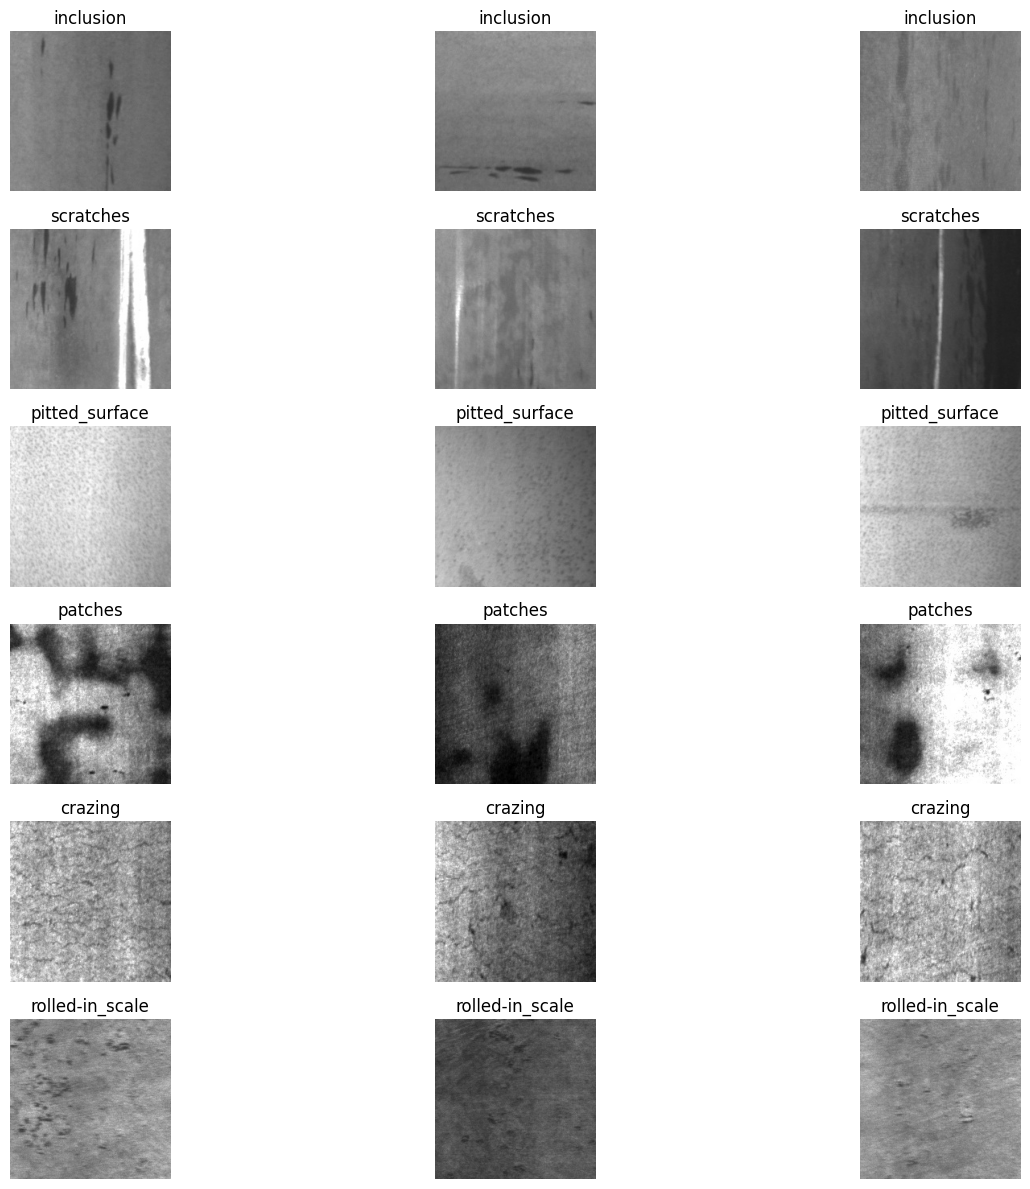

In [10]:
classes=os.listdir(train_image_path)

plt.figure(figsize=(15,12))

plot_no=1

for category in classes:

    folder=os.path.join(train_image_path,category)
    images=os.listdir(folder)

    for image in images[:3]:

        img=Image.open(
            os.path.join(folder,image)
        ).convert("RGB")

        plt.subplot(6,3,plot_no)
        plt.imshow(img)
        plt.axis("off")
        plt.title(category)

        plot_no+=1

plt.tight_layout()
plt.show()

Now we optimize the data pipeline before training.
Cache keeps the loaded images available in memory and prefetch prepares batches ahead of time.
--

In [60]:
train_data=train_data.cache().prefetch(tf.data.AUTOTUNE)
validation_data=validation_data.cache().prefetch(tf.data.AUTOTUNE)

Now we build the CNN that will learn patterns from the defect images.
The convolution and pooling layers extract features, while the Dense layers classify them into six defect categories.
--

In [44]:
model=Sequential([

    Input(shape=(128,128,3)),

    Rescaling(1./255),

    Conv2D(
        filters=128,
        kernel_size=(3,3),
        strides=(1,1),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2,2)
    ),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        strides=(1,1),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2,2)
    ),

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=(1,1),
        activation="relu"
    ),

    MaxPooling2D(
        pool_size=(2,2)
    ),

    Flatten(),

    Dense(
        units=64,
        activation="relu"
    ),

    Dense(
        units=6,
        activation="softmax"
    )
])

We check the complete architecture before starting training.
This confirms the layers, output shapes and total number of trainable parameters.
--

In [45]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [46]:
early_stopping=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

We add EarlyStopping so training doesn't continue unnecessarily once validation performance stops improving.
The best model weights are restored automatically.
--

In [48]:
history=model.fit(
    train_data,
    validation_data=validation_data,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.1868 - loss: 1.7638 - val_accuracy: 0.2583 - val_loss: 1.6987
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4250 - loss: 1.4588 - val_accuracy: 0.6111 - val_loss: 1.3871
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6299 - loss: 1.0906 - val_accuracy: 0.6111 - val_loss: 1.0461
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7632 - loss: 0.7112 - val_accuracy: 0.6583 - val_loss: 0.8258
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8257 - loss: 0.5154 - val_accuracy: 0.7639 - val_loss: 0.6625
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8771 - loss: 0.3878 - val_accuracy: 0.8806 - val_loss: 0.3728
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9222 - loss: 0.2693 - val_accuracy: 0.8528 - val_loss: 0.3993
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9292 - loss: 0.2325 - val_accuracy: 0.

In [49]:
loss,accuracy=model.evaluate(validation_data)

print("Validation Loss:",loss)
print("Validation Accuracy:",accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8778 - loss: 0.2531
Validation Loss: 0.25311797857284546
Validation Accuracy: 0.8777777552604675


After training, we evaluate the CNN on the validation dataset.
Our final result is 87.78% validation accuracy with 0.2531 validation loss.
--

In [50]:
y_pred=model.predict(validation_data)

y_pred=np.argmax(y_pred,axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


Now we use the trained CNN to predict the defect class for every validation image.
Argmax selects the class with the highest predicted probability.
--

In [51]:
y_true=[]

for images,labels in validation_data:
    y_true.extend(labels.numpy())

y_true=np.array(y_true)

Here we collect the actual labels from the validation dataset.
These labels will be compared with our CNN predictions for detailed evaluation.
--

In [52]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                 precision    recall  f1-score   support

        crazing       0.91      1.00      0.95        60
      inclusion       0.91      0.68      0.78        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.74      0.87      0.80        60
rolled-in_scale       1.00      0.82      0.90        60
      scratches       0.77      0.90      0.83        60

       accuracy                           0.88       360
      macro avg       0.89      0.88      0.88       360
   weighted avg       0.89      0.88      0.88       360



We compare the predicted and actual labels to calculate precision, recall and F1-score for every defect.
This helps us see which defect categories the model performs well on.
--

In [53]:
cm=confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[60  0  0  0  0  0]
 [ 0 41  0 18  0  1]
 [ 0  0 60  0  0  0]
 [ 2  2  0 52  0  4]
 [ 0  0  0  0 49 11]
 [ 4  2  0  0  0 54]]


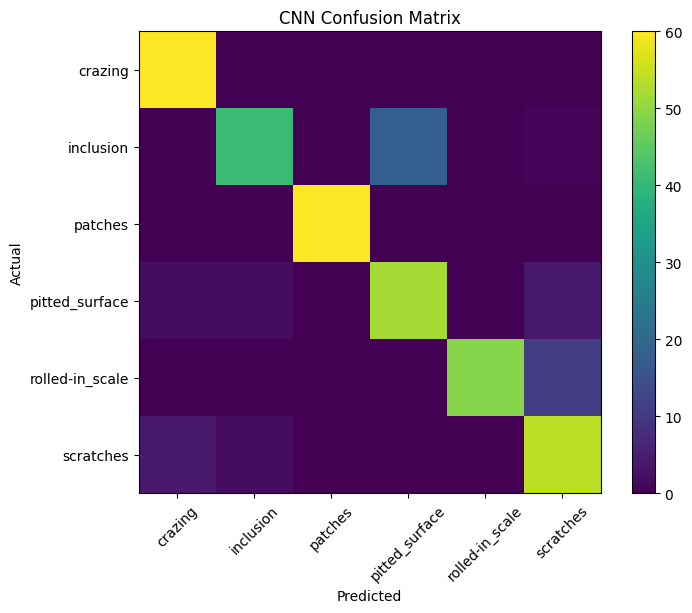

In [54]:
plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.colorbar()
plt.show()

The confusion matrix shows exactly which defect classes were predicted correctly and which were confused with each other.
This helps us identify the main classification errors.
--


# Finally, we save the trained CNN as a `.keras` file.
This allows us to load the trained model later without training it again.
--


In [61]:
model.save("neu_defect_cnn.keras")

print("CNN model exported successfully!")

CNN model exported successfully!
